In [1]:
# coding: utf-8
__author__ = "Nicholas Metherall"
__copyright__ = "Copyright 2025, The Pacific Community (SPC)"
__license__ = "CreativeCommons"
__version__ = "0.1"
__email__ = "nicholasm@spc.int"
__status__ = "Development"

import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd
import numpy as np
from fiona.crs import from_epsg
import shapely
import warnings
from shapely.ops import unary_union
from shapely.geometry import box
warnings.filterwarnings('ignore')
# coastal ndti

<Axes: >

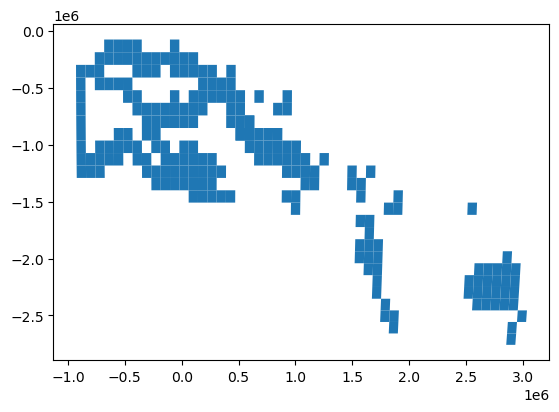

In [2]:
coastline_lines = gpd.read_file("coastline_lines.geojson")
coastal_grids = gpd.read_file("coastal_macblue_grids.geojson")
coastal_grids.plot()

In [3]:
coastal_grids

,level_1,GID_0,COUNTRY,index,uuid,index_right,geometry
0,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2853497.38 -2758834.497, 2860754.992..."
1,17,VUT,Vanuatu,2,VUT2,0,"POLYGON ((1820480.449 -2658691.923, 1824951.85..."
2,17,FJI,Fiji,3,FJI3,0,"POLYGON ((2860754.992 -2658691.923, 2867781.49..."
3,18,VUT,Vanuatu,4,VUT4,0,"POLYGON ((1744734.194 -2557719.247, 1748864.58..."
4,18,VUT,Vanuatu,5,VUT5,0,"POLYGON ((1824951.858 -2557719.247, 1829272.15..."
...,...,...,...,...,...,...,...
201,40,PNG,Papua New Guinea,225,PNG225,0,"POLYGON ((-681479.65 -185890.359, -681566.064 ..."
202,40,PNG,Papua New Guinea,226,PNG226,0,"POLYGON ((-598876.056 -185890.359, -598951.995..."
203,40,PNG,Papua New Guinea,227,PNG227,0,"POLYGON ((-516272.462 -185890.359, -516337.927..."
204,40,PNG,Papua New Guinea,228,PNG228,0,"POLYGON ((-433668.868 -185890.359, -433723.859..."


In [8]:
def twentyfifths(grid):
    minx, miny, maxx, maxy = grid.bounds
    width = (maxx - minx) / 8
    height = (maxy - miny) / 8
    result = []
    idx = 1
    for i in range(8):
        for j in range(8):
            x1 = minx + i * width
            x2 = minx + (i + 1) * width
            y1 = miny + j * height
            y2 = miny + (j + 1) * height
            result.append((box(x1, y1, x2, y2), f'Q{idx}'))
            idx += 1
    return result

# Build a list of dicts for each sub-square
records = []
for idx, row in coastal_grids.iterrows():
    for geom, twentyfifth_name in twentyfifths(row.geometry):
        rec = row.to_dict()
        rec['geometry'] = geom
        rec['twentyfifth'] = twentyfifth_name
        records.append(rec)

twentyfifths_gdf = gpd.GeoDataFrame(records, crs=coastal_grids.crs)

In [9]:
twentyfifths_gdf['quid'] = twentyfifths_gdf['uuid']+twentyfifths_gdf['twentyfifth']+'_'+twentyfifths_gdf['level_1'].astype(str)

In [10]:
twentyfifths_gdf

,level_1,GID_0,COUNTRY,index,uuid,index_right,geometry,twentyfifth,quid
0,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2758834.497, 2864407.22...",Q1,FJI1Q1_16
1,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2746316.676, 2864407.22...",Q2,FJI1Q2_16
2,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2733798.854, 2864407.22...",Q3,FJI1Q3_16
3,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2721281.032, 2864407.22...",Q4,FJI1Q4_16
4,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2708763.21, 2864407.221...",Q5,FJI1Q5_16
...,...,...,...,...,...,...,...,...,...
13179,40,PNG,Papua New Guinea,229,PNG229,0,"POLYGON ((-20650.898 -144068.796, -20650.898 -...",Q60,PNG229Q60_40
13180,40,PNG,Papua New Guinea,229,PNG229,0,"POLYGON ((-20650.898 -130128.274, -20650.898 -...",Q61,PNG229Q61_40
13181,40,PNG,Papua New Guinea,229,PNG229,0,"POLYGON ((-20650.898 -116187.753, -20650.898 -...",Q62,PNG229Q62_40
13182,40,PNG,Papua New Guinea,229,PNG229,0,"POLYGON ((-20650.898 -102247.232, -20650.898 -...",Q63,PNG229Q63_40


In [11]:
# Collect all new rows as dicts
records = []
for idx, row in twentyfifths_gdf.iterrows():
    for geom, twentyfifth_name in twentyfifth(row.geometry):
        rec = row.to_dict()
        rec['geometry'] = geom
        rec['twentyfifth'] = twentyfifth_name  # Optional: label the twentyfifth
        records.append(rec)

twentyfifths_gdf = gpd.GeoDataFrame(records, crs=coastal_grids.crs)

NameError: name 'twentyfifth' is not defined

<Axes: >

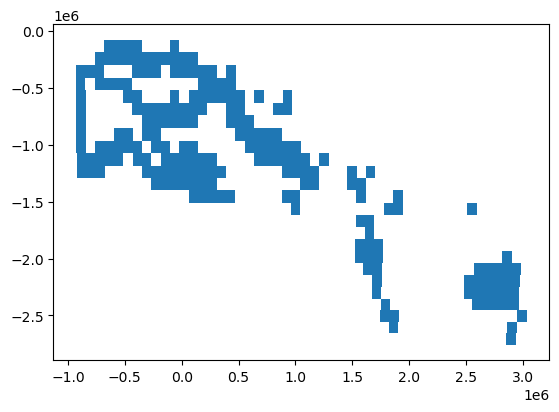

In [12]:
twentyfifths_gdf.plot()

In [13]:
twentyfifths_gdf

,level_1,GID_0,COUNTRY,index,uuid,index_right,geometry,twentyfifth,quid
0,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2758834.497, 2864407.22...",Q1,FJI1Q1_16
1,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2746316.676, 2864407.22...",Q2,FJI1Q2_16
2,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2733798.854, 2864407.22...",Q3,FJI1Q3_16
3,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2721281.032, 2864407.22...",Q4,FJI1Q4_16
4,16,FJI,Fiji,1,FJI1,0,"POLYGON ((2864407.221 -2708763.21, 2864407.221...",Q5,FJI1Q5_16
...,...,...,...,...,...,...,...,...,...
13179,40,PNG,Papua New Guinea,229,PNG229,0,"POLYGON ((-20650.898 -144068.796, -20650.898 -...",Q60,PNG229Q60_40
13180,40,PNG,Papua New Guinea,229,PNG229,0,"POLYGON ((-20650.898 -130128.274, -20650.898 -...",Q61,PNG229Q61_40
13181,40,PNG,Papua New Guinea,229,PNG229,0,"POLYGON ((-20650.898 -116187.753, -20650.898 -...",Q62,PNG229Q62_40
13182,40,PNG,Papua New Guinea,229,PNG229,0,"POLYGON ((-20650.898 -102247.232, -20650.898 -...",Q63,PNG229Q63_40


In [14]:
# Remove index_right if it exists
if 'index_right' in twentyfifths_gdf.columns:
    twentyfifths_gdf = twentyfifths_gdf.drop(columns='index_right')

if 'index_right' in coastline_lines.columns:
    coastline_lines = coastline_lines.drop(columns='index_right')

<Axes: >

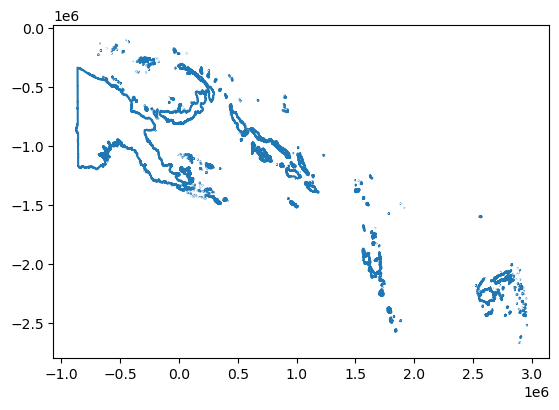

In [15]:
coastline_lines.plot()

In [16]:
# Only keep grids that intersect with any coastline
coastline_lines = gpd.read_file("coastline_lines.geojson")

subset = gpd.sjoin(twentyfifths_gdf, coastline_lines, how="inner", predicate="intersects")


In [17]:
subset

,level_1,GID_0,COUNTRY,index,uuid,geometry,twentyfifth,quid,index_right
30,16,FJI,Fiji,1,FJI1,"POLYGON ((2897136.745 -2683727.567, 2897136.74...",Q31,FJI1Q31_16,0
39,16,FJI,Fiji,1,FJI1,"POLYGON ((2908046.587 -2671209.745, 2908046.58...",Q40,FJI1Q40_16,0
78,17,VUT,Vanuatu,2,VUT2,"POLYGON ((1841652.718 -2582962.416, 1841652.71...",Q15,VUT2Q15_17,0
79,17,VUT,Vanuatu,2,VUT2,"POLYGON ((1841652.718 -2570340.832, 1841652.71...",Q16,VUT2Q16_17,0
86,17,VUT,Vanuatu,2,VUT2,"POLYGON ((1852238.852 -2582962.416, 1852238.85...",Q23,VUT2Q23_17,0
...,...,...,...,...,...,...,...,...,...
13160,40,PNG,Papua New Guinea,229,PNG229,"POLYGON ((-41305.07 -185890.359, -41305.07 -17...",Q41,PNG229Q41_40,0
13161,40,PNG,Papua New Guinea,229,PNG229,"POLYGON ((-41305.07 -171949.838, -41305.07 -15...",Q42,PNG229Q42_40,0
13168,40,PNG,Papua New Guinea,229,PNG229,"POLYGON ((-30977.984 -185890.359, -30977.984 -...",Q49,PNG229Q49_40,0
13169,40,PNG,Papua New Guinea,229,PNG229,"POLYGON ((-30977.984 -171949.838, -30977.984 -...",Q50,PNG229Q50_40,0


<Axes: >

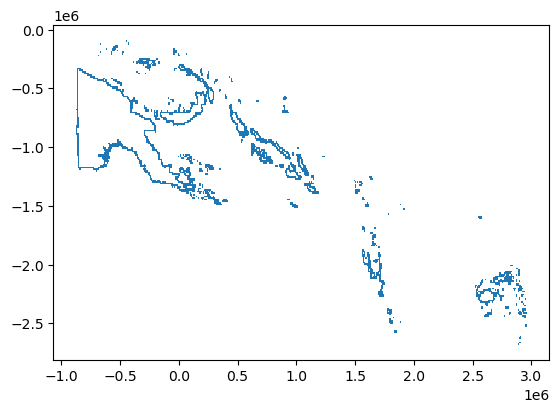

In [18]:
subset.plot()

In [19]:
twentyfifth_grids = subset
twentyfifth_grids.to_file("twentyfifth_grids.geojson")
